# Imports and Setup & Dataload

In [1]:
# ── Core Libraries ─────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Preprocessing ──────────────────────────────────────────────
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import (
    train_test_split, cross_val_score,
    StratifiedKFold, GridSearchCV, learning_curve
)

# ── Models ─────────────────────────────────────────────────────
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression, SGDClassifier

# ── Metrics ────────────────────────────────────────────────────
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix
)

# ── Settings ───────────────────────────────────────────────────
pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100

print("✓ Libraries imported successfully.")

✓ Libraries imported successfully.


In [2]:
# Load the NYC Food Safety Inspections dataset
df = pd.read_csv("/content/Food_Safety_Inspections_–_Current_Ratings_20251215.csv")

# Sample 30% for computational efficiency
df = df.sample(frac=0.3, random_state=42)

print("✓ Dataset loaded and sampled successfully!")
print(f"\nSampled Dataset Shape: {df.shape}")
print("\nFirst 5 rows:")
display(df.head())

✓ Dataset loaded and sampled successfully!

Sampled Dataset Shape: (41075, 13)

First 5 rows:


,County,Inspection Grade,Inspection Date,Establishment Types,Owner Name,Trade Name,Street,City,State Code,Zip Code,Deficiency Number,Deficiency Description,Georeference
123756,Suffolk,A,10/02/2024,AC,3 BROTHERS 1 CORP,USA FOOD MART,1290 NEW YORK AVE,HUNTINGTON STATION,NY,11746,NaN,NaN,POINT (-73.41157 40.85059)
103373,Queens,A,01/18/2024,A,FAMILY DOLLAR STORES OF NEW YORK,FAMILY DOLLAR #31381,11322 ROCKAWAY BEACH BLVD,ROCKAWAY PARK,NY,11694,NaN,NaN,POINT (-73.83523 40.58037)
8838,Bronx,C,07/30/2024,A,GREEN OLIVES FAST MART INC,GREEN OLIVES FAST MART,716B MORRIS PARK AVE,BRONX,NY,10462,10B,Establishment has insufficient space to accomm...,POINT (-73.86537 40.84538)
77426,New York,C,12/28/2023,AC,5 SENSES DELI,5 SENSES DELI,206 3RD AVE,NEW YORK,NY,10003,13B,- Allergen notice for staff is not posted for ...,POINT (-73.98529 40.73589)
135465,Westchester,C,07/21/2025,AC,MELANNE INC,GEORDANES MRKT,57 MAIN ST,IRVINGTON,NY,10533,15F,Bottom shelves on the processing tables in the...,POINT (-73.86966 41.03941)


# Data Overview and Analysis

In [3]:
# ── Basic dataset information ───────────────────────────────────
print("=" * 55)
print("DATASET OVERVIEW")
print("=" * 55)

print(f"\nRows    : {df.shape[0]:,}")
print(f"Columns : {df.shape[1]}")

print("\n--- Column Names & Data Types ---")
print(df.dtypes)

DATASET OVERVIEW

Rows    : 41,075
Columns : 13

--- Column Names & Data Types ---
County                    object
Inspection Grade          object
Inspection Date           object
Establishment Types       object
Owner Name                object
Trade Name                object
Street                    object
City                      object
State Code                object
Zip Code                   int64
Deficiency Number         object
Deficiency Description    object
Georeference              object
dtype: object


In [4]:
# ── Statistical summary of the dataset ─────────────────────────
print("=" * 55)
print("STATISTICAL SUMMARY")
print("=" * 55)

print("\n--- Numerical Columns ---")
display(df.describe())

print("\n--- Categorical Columns ---")
display(df.describe(include='object'))

STATISTICAL SUMMARY

--- Numerical Columns ---


,Zip Code
count,41075.000000
mean,11636.190578
std,1314.608829
min,6390.000000
25%,10573.000000
50%,11230.000000
75%,12180.000000
max,14905.000000



--- Categorical Columns ---


,County,Inspection Grade,Inspection Date,Establishment Types,Owner Name,Trade Name,Street,City,State Code,Deficiency Number,Deficiency Description,Georeference
count,41075,41075,41075,41074,41075,41024,41075,41075,41075,31623,31623,40856
unique,62,3,511,114,10960,12708,13292,1111,1,70,25005,12881
top,Kings,C,07/11/2024,AC,DOLGEN NEW YORK LLC,KEY FOOD,6719 BAY PARKWAY,BROOKLYN,NY,10C,Proper sanitizer test devices are not availabl...,POINT (-73.95066 40.70522)
freq,10872,21632,146,31138,372,126,36,10871,41075,2245,242,36


MISSING VALUES ANALYSIS

Total Missing Values: 19,175
Total Cells        : 533,975



,Column,Missing Count,Missing %
0,Deficiency Description,9452,23.01
1,Deficiency Number,9452,23.01
2,Georeference,219,0.53
3,Trade Name,51,0.12
4,Establishment Types,1,0.00
5,Owner Name,0,0.00
6,Inspection Date,0,0.00
7,Inspection Grade,0,0.00
8,County,0,0.00
9,State Code,0,0.00


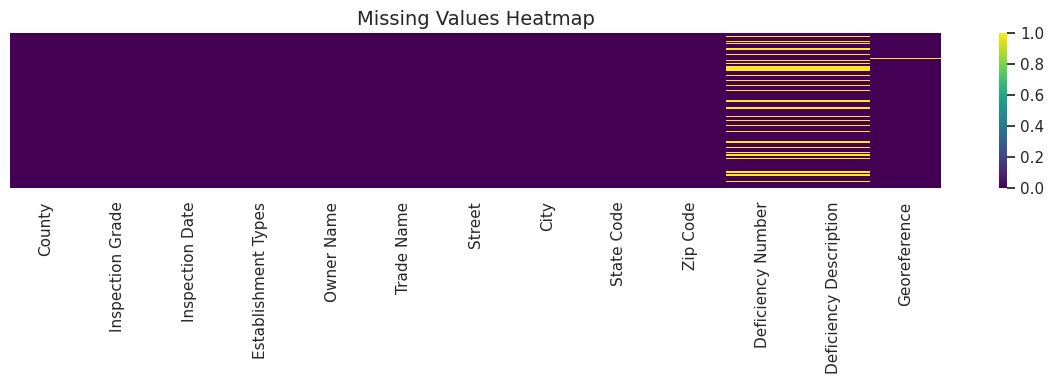

In [5]:
# ── Check for missing values in each column ─────────────────────
print("=" * 55)
print("MISSING VALUES ANALYSIS")
print("=" * 55)

missing = pd.DataFrame({
    'Column': df.columns,
    'Missing Count': df.isnull().sum().values,
    'Missing %': (df.isnull().sum().values / len(df) * 100).round(2)
})

missing = missing.sort_values('Missing Count', ascending=False)
missing = missing.reset_index(drop=True)

print(f"\nTotal Missing Values: {df.isnull().sum().sum():,}")
print(f"Total Cells        : {df.shape[0] * df.shape[1]:,}")
print()
display(missing)

# Visual missing value heatmap
plt.figure(figsize=(12, 4))
sns.heatmap(df.isnull(),
            yticklabels=False,
            cbar=True,
            cmap='viridis')
plt.title("Missing Values Heatmap", fontsize=14)
plt.tight_layout()
plt.show()

# EDA

## Target Distribution Visualization

TARGET VARIABLE — INSPECTION GRADE

Value Counts:
Inspection Grade
C    21632
B     9991
A     9452
Name: count, dtype: int64

Class Balance:
Inspection Grade
C    52.66%
B    24.32%
A    23.01%
Name: proportion, dtype: object


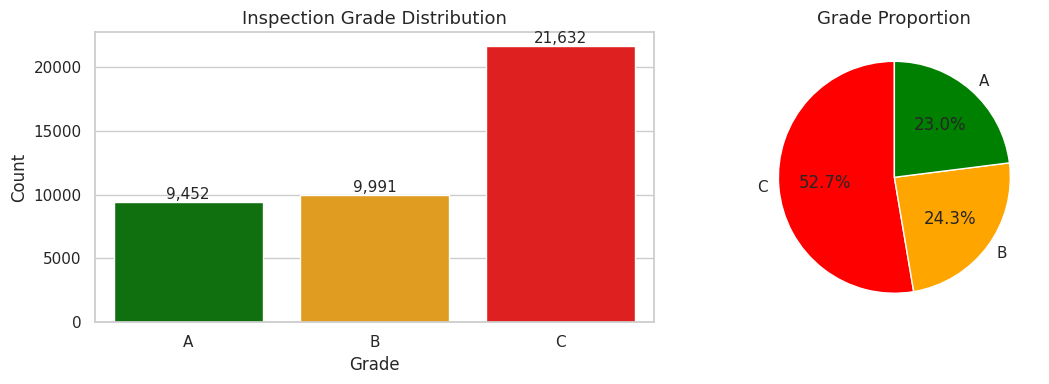

In [6]:
# ── Visualize the distribution of the target variable ───────────
print("=" * 55)
print("TARGET VARIABLE — INSPECTION GRADE")
print("=" * 55)

print("\nValue Counts:")
print(df['Inspection Grade'].value_counts())
print("\nClass Balance:")
print(df['Inspection Grade'].value_counts(normalize=True).map(
    lambda x: f"{x*100:.2f}%"
))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
ax = sns.countplot(
    data=df, x='Inspection Grade',
    order=['A', 'B', 'C'],
    palette=['green', 'orange', 'red'],
    ax=axes[0]
)
axes[0].set_title("Inspection Grade Distribution", fontsize=13)
axes[0].set_xlabel("Grade")
axes[0].set_ylabel("Count")
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=11)

# Pie chart
df['Inspection Grade'].value_counts().plot(
    kind='pie',
    ax=axes[1],
    autopct='%1.1f%%',
    colors=['red', 'orange', 'green'],
    startangle=90
)
axes[1].set_title("Grade Proportion", fontsize=13)
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

## Establishment Types Analysis

ESTABLISHMENT TYPES ANALYSIS

Top 15 Establishment Types:
Establishment Types
AC      31138
A        3127
ABC      1962
C         951
D         477
CDK       301
ABCH      280
V         232
CD        221
B         212
ACH       206
DK        191
ABCK      134
ACD       118
CK        118
Name: count, dtype: int64


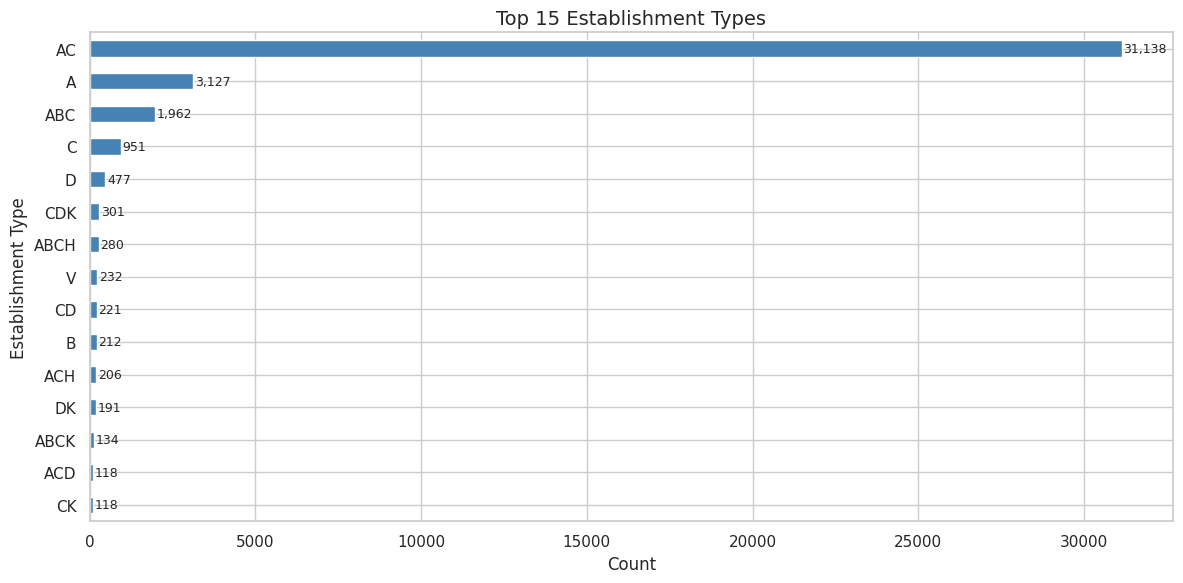

In [7]:
# ── Analyze top establishment types ─────────────────────────────
print("=" * 55)
print("ESTABLISHMENT TYPES ANALYSIS")
print("=" * 55)

top_types = df['Establishment Types'].value_counts().head(15)

print("\nTop 15 Establishment Types:")
print(top_types)

plt.figure(figsize=(12, 6))
ax = top_types.plot(kind='barh', color='steelblue')
plt.title("Top 15 Establishment Types", fontsize=14)
plt.xlabel("Count")
plt.ylabel("Establishment Type")
for i, (val, name) in enumerate(zip(top_types.values, top_types.index)):
    plt.text(val + 50, i, f'{val:,}', va='center', fontsize=9)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Geographic Distribution

GEOGRAPHIC DISTRIBUTION


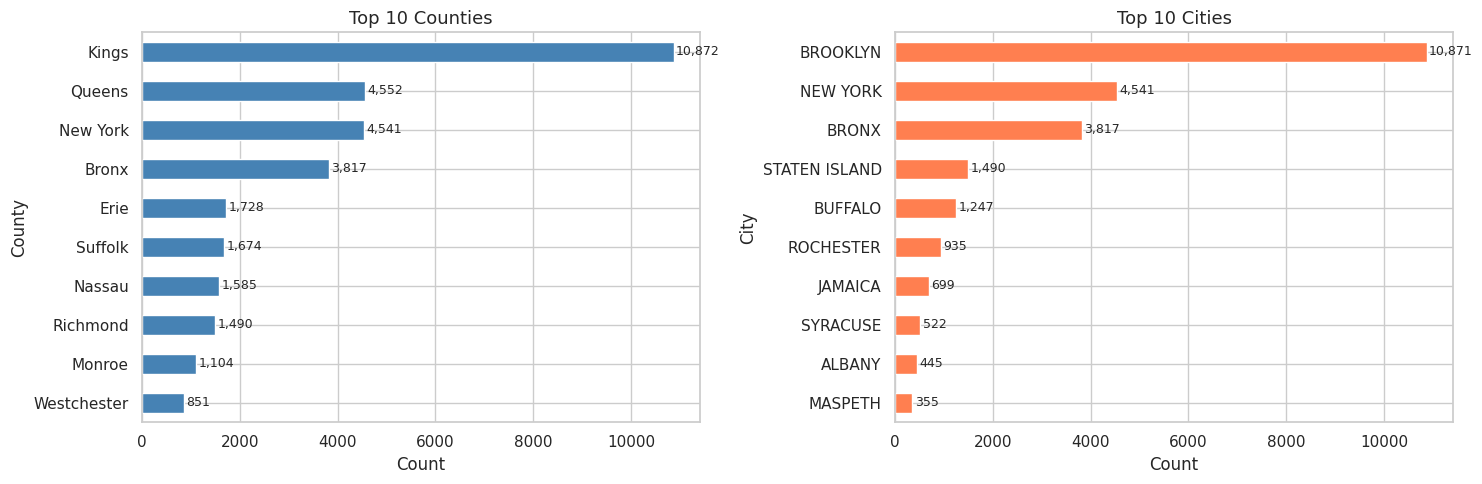


Top 10 Counties:
County
Kings          10872
Queens          4552
New York        4541
Bronx           3817
Erie            1728
Suffolk         1674
Nassau          1585
Richmond        1490
Monroe          1104
Westchester      851
Name: count, dtype: int64

Top 10 Cities:
City
BROOKLYN         10871
NEW YORK          4541
BRONX             3817
STATEN ISLAND     1490
BUFFALO           1247
ROCHESTER          935
JAMAICA            699
SYRACUSE           522
ALBANY             445
MASPETH            355
Name: count, dtype: int64


In [8]:
# ── Analyze geographic distribution by county and city ──────────
print("=" * 55)
print("GEOGRAPHIC DISTRIBUTION")
print("=" * 55)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Top 10 Counties
county_dist = df['County'].value_counts().head(10)
county_dist.plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title("Top 10 Counties", fontsize=13)
axes[0].set_xlabel("Count")
axes[0].set_ylabel("County")
for i, val in enumerate(county_dist.values):
    axes[0].text(val + 50, i, f'{val:,}', va='center', fontsize=9)
axes[0].invert_yaxis()

# Top 10 Cities
city_dist = df['City'].value_counts().head(10)
city_dist.plot(kind='barh', ax=axes[1], color='coral')
axes[1].set_title("Top 10 Cities", fontsize=13)
axes[1].set_xlabel("Count")
axes[1].set_ylabel("City")
for i, val in enumerate(city_dist.values):
    axes[1].text(val + 50, i, f'{val:,}', va='center', fontsize=9)
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

print("\nTop 10 Counties:")
print(county_dist)
print("\nTop 10 Cities:")
print(city_dist)

## Time Series Analysis

TIME SERIES ANALYSIS


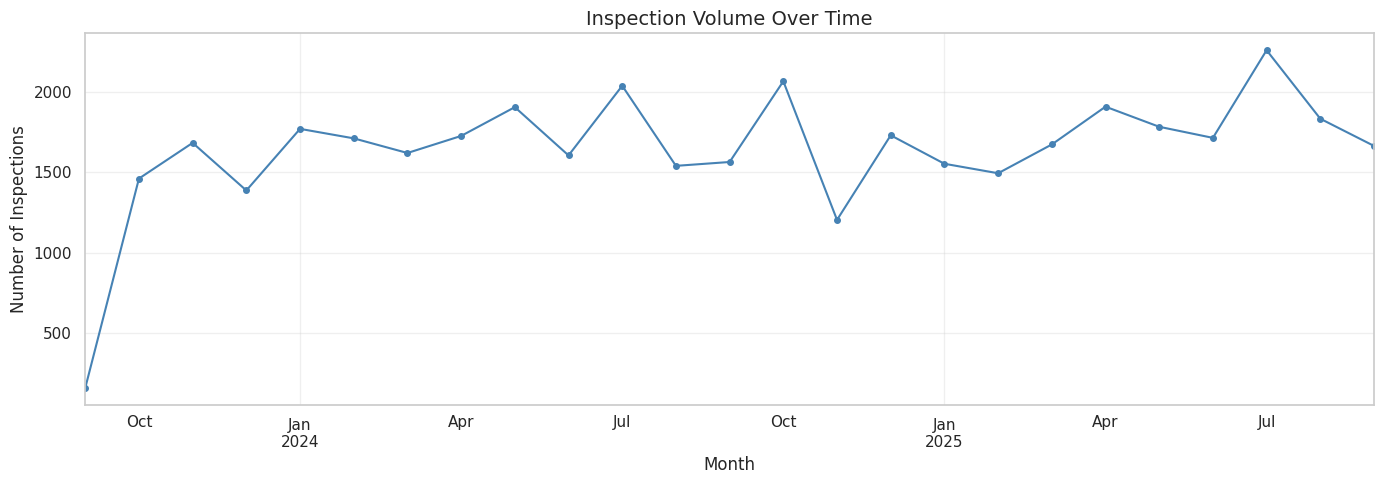


Recent 12 Months of Inspections:
Inspection Date
2024-10    2067
2024-11    1205
2024-12    1731
2025-01    1554
2025-02    1495
2025-03    1674
2025-04    1909
2025-05    1784
2025-06    1715
2025-07    2260
2025-08    1834
2025-09    1665
Freq: M, dtype: int64


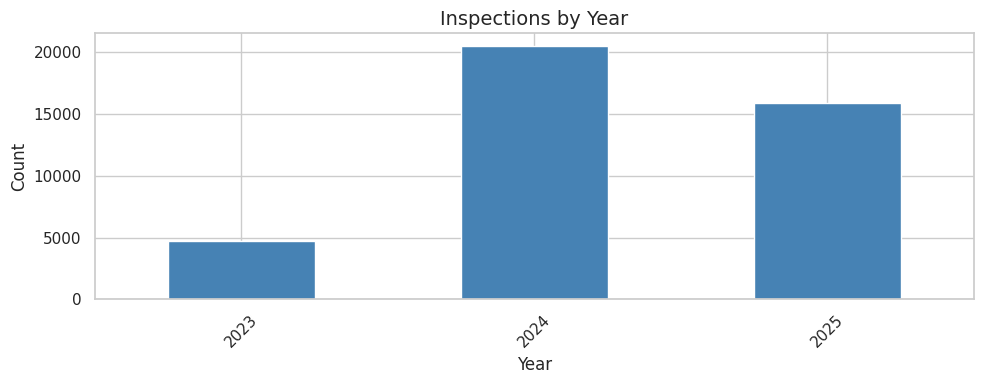

In [9]:
# ── Analyze inspection volume over time ─────────────────────────
print("=" * 55)
print("TIME SERIES ANALYSIS")
print("=" * 55)

# Convert date column
df['Inspection Date'] = pd.to_datetime(df['Inspection Date'])

# Extract time features
df['Year']      = df['Inspection Date'].dt.year
df['Month']     = df['Inspection Date'].dt.month
df['Quarter']   = df['Inspection Date'].dt.quarter
df['DayOfWeek'] = df['Inspection Date'].dt.dayofweek

# Monthly inspection volume
monthly = df.groupby(df['Inspection Date'].dt.to_period('M')).size()

plt.figure(figsize=(14, 5))
monthly.plot(kind='line', marker='o', markersize=4, color='steelblue')
plt.title("Inspection Volume Over Time", fontsize=14)
plt.xlabel("Month")
plt.ylabel("Number of Inspections")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nRecent 12 Months of Inspections:")
print(monthly.tail(12))

# Inspections by year
plt.figure(figsize=(10, 4))
df['Year'].value_counts().sort_index().plot(
    kind='bar', color='steelblue'
)
plt.title("Inspections by Year", fontsize=14)
plt.xlabel("Year")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Grade by Establishment Type

GRADE BY ESTABLISHMENT TYPE

Grade Distribution (%) for Top 10 Types:
Inspection Grade         A      B      C
Establishment Types                     
AC                   18.85  27.54  53.62
A                    55.71   7.36  36.94
ABC                  21.56  35.52  42.92
C                    42.38  13.88  43.74
D                    45.28   2.10  52.62
CDK                  18.60   5.65  75.75
ABCH                 12.14  15.00  72.86
V                    32.33  15.52  52.16
CD                   24.43   4.07  71.49
B                    18.40   9.91  71.70


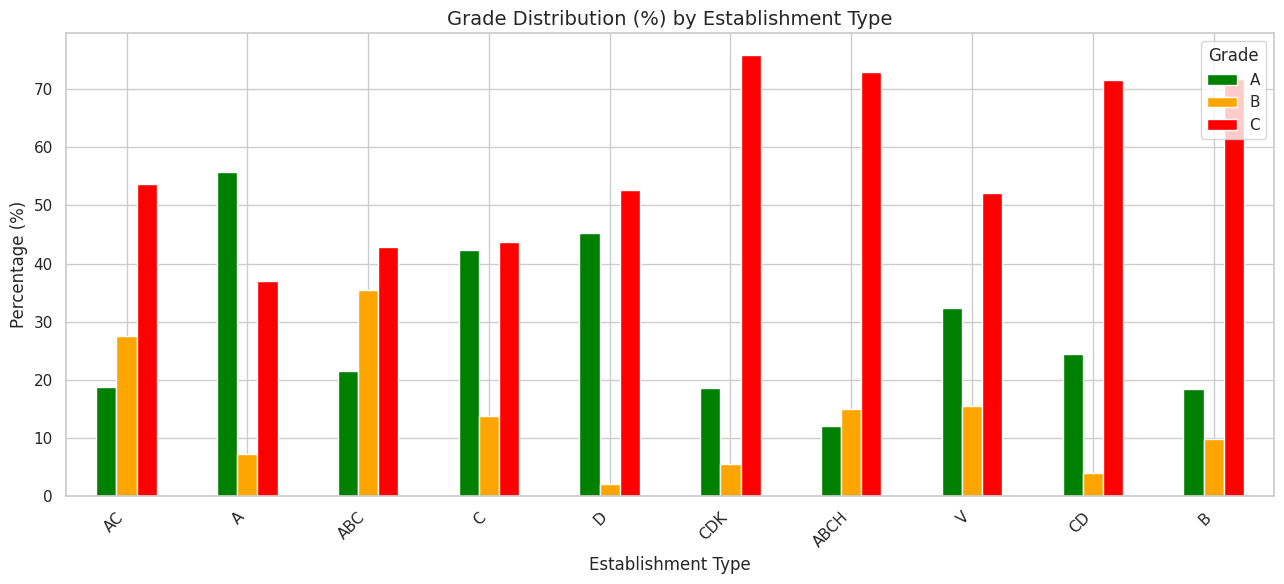

In [10]:
# ── Grade distribution by establishment type ────────────────────
print("=" * 55)
print("GRADE BY ESTABLISHMENT TYPE")
print("=" * 55)

# Get top 10 establishment types
top_types_list = df['Establishment Types'].value_counts().head(10).index

# Cross tabulation normalized by row
grade_by_type = pd.crosstab(
    df['Establishment Types'],
    df['Inspection Grade'],
    normalize='index'
) * 100

print("\nGrade Distribution (%) for Top 10 Types:")
print(grade_by_type.loc[top_types_list].round(2))

# Plot
grade_by_type.loc[top_types_list].plot(
    kind='bar',
    figsize=(13, 6),
    color=['green', 'orange', 'red']
)
plt.title("Grade Distribution (%) by Establishment Type", fontsize=14)
plt.xlabel("Establishment Type")
plt.ylabel("Percentage (%)")
plt.legend(title='Grade', loc='upper right')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

GRADE BY COUNTY

Grade Distribution (%) by Top 10 Counties:
Inspection Grade      A      B      C
County                               
Kings              8.95  26.95  64.10
Queens            21.57  20.54  57.89
New York          17.55  35.61  46.84
Bronx             19.75  15.82  64.42
Erie              36.75  22.57  40.68
Suffolk           48.45  16.79  34.77
Nassau            26.56  24.98  48.45
Richmond          20.54  26.64  52.82
Monroe            42.84  19.75  37.41
Westchester       35.02  20.56  44.42


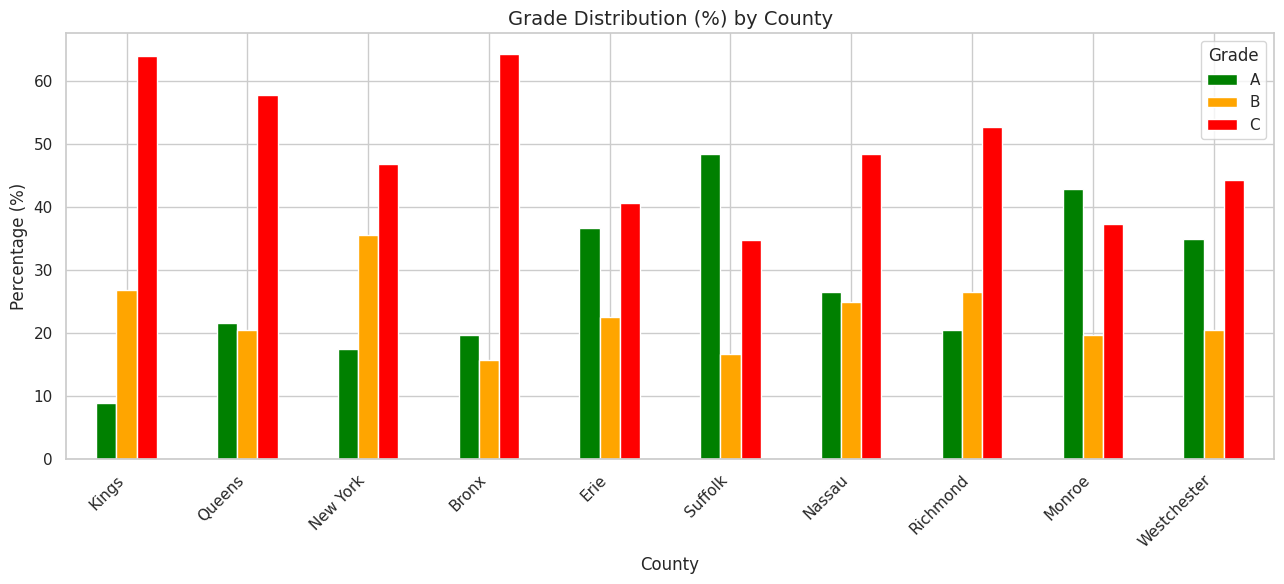

In [11]:
# ── Grade distribution by county ────────────────────────────────
print("=" * 55)
print("GRADE BY COUNTY")
print("=" * 55)

# Top 10 counties
top_counties = df['County'].value_counts().head(10).index

grade_by_county = pd.crosstab(
    df['County'],
    df['Inspection Grade'],
    normalize='index'
) * 100

print("\nGrade Distribution (%) by Top 10 Counties:")
print(grade_by_county.loc[top_counties].round(2))

# Plot
grade_by_county.loc[top_counties].plot(
    kind='bar',
    figsize=(13, 6),
    color=['green', 'orange', 'red']
)
plt.title("Grade Distribution (%) by County", fontsize=14)
plt.xlabel("County")
plt.ylabel("Percentage (%)")
plt.legend(title='Grade', loc='upper right')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

GRADE BY YEAR

Grade Distribution (%) by Year:
Inspection Grade      A      B      C
Year                                 
2023              23.56  22.16  54.28
2024              23.08  23.91  53.01
2025              22.76  25.49  51.74


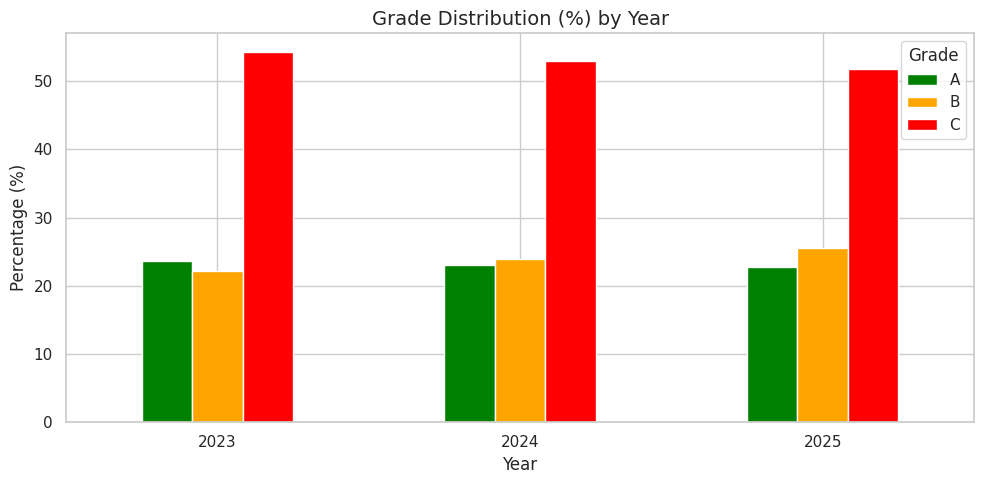

In [12]:
# ── Grade distribution by year ───────────────────────────────────
print("=" * 55)
print("GRADE BY YEAR")
print("=" * 55)

grade_by_year = pd.crosstab(
    df['Year'],
    df['Inspection Grade'],
    normalize='index'
) * 100

print("\nGrade Distribution (%) by Year:")
print(grade_by_year.round(2))

grade_by_year.plot(
    kind='bar',
    figsize=(10, 5),
    color=['green', 'orange', 'red']
)
plt.title("Grade Distribution (%) by Year", fontsize=14)
plt.xlabel("Year")
plt.ylabel("Percentage (%)")
plt.legend(title='Grade')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

CORRELATION HEATMAP


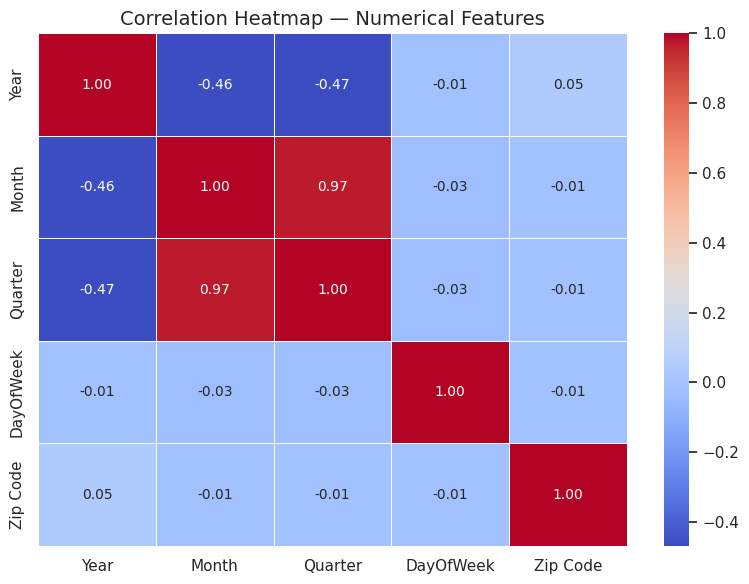

In [13]:
# ── Correlation heatmap of numerical features ────────────────────
print("=" * 55)
print("CORRELATION HEATMAP")
print("=" * 55)

num_df = df[['Year', 'Month', 'Quarter', 'DayOfWeek', 'Zip Code']].copy()

plt.figure(figsize=(8, 6))
sns.heatmap(
    num_df.corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    linewidths=0.5,
    annot_kws={"size": 10}
)
plt.title("Correlation Heatmap — Numerical Features", fontsize=14)
plt.tight_layout()
plt.show()

## 🔧 Feature Engineering & Preprocessing

In [14]:
# ── Create new features from existing columns ────────────────────
print("=" * 55)
print("FEATURE ENGINEERING")
print("=" * 55)

df_fe = df.copy()

# Feature 1: Length of establishment type string
df_fe['Has_Multiple_Types'] = df_fe['Establishment Types'].str.len()

# Feature 2: Flag if establishment is in NYC borough
df_fe['Is_NYC'] = df_fe['County'].isin(
    ['Kings', 'Queens', 'Bronx', 'New York', 'Richmond']
).astype(int)

# Feature 3: Extract coordinates from Georeference
def extract_coordinates(geo_str):
    if pd.isna(geo_str):
        return None, None
    try:
        coords = geo_str.replace('POINT (', '').replace(')', '').split()
        return float(coords[0]), float(coords[1])
    except:
        return None, None

df_fe['Longitude'], df_fe['Latitude'] = zip(
    *df_fe['Georeference'].apply(extract_coordinates)
)

# Feature 4: Previous grade per establishment
df_sorted = df_fe.sort_values('Inspection Date')
df_sorted['Previous_Grade'] = df_sorted.groupby(
    ['Trade Name', 'Street']
)['Inspection Grade'].shift(1)

# Feature 5: Days since last inspection
df_sorted['Days_Since_Last'] = df_sorted.groupby(
    ['Trade Name', 'Street']
)['Inspection Date'].diff().dt.days

# Feature 6: Total inspections per establishment
df_sorted['Total_Inspections'] = df_sorted.groupby(
    ['Trade Name', 'Street']
).cumcount() + 1

# Feature 7: Historical failure rate per establishment
establishment_stats = df_sorted.groupby(
    ['Trade Name', 'Street']
)['Inspection Grade'].agg(
    lambda x: (x == 'C').sum() / len(x)
).reset_index()
establishment_stats.columns = ['Trade Name', 'Street', 'Failure_Rate']
df_sorted = df_sorted.merge(
    establishment_stats, on=['Trade Name', 'Street'], how='left'
)

df_fe = df_sorted.copy()

print("✓ New features created:")
new_features = ['Has_Multiple_Types', 'Is_NYC', 'Longitude',
                'Latitude', 'Previous_Grade', 'Days_Since_Last',
                'Total_Inspections', 'Failure_Rate']
for f in new_features:
    print(f"  → {f}")

FEATURE ENGINEERING
✓ New features created:
  → Has_Multiple_Types
  → Is_NYC
  → Longitude
  → Latitude
  → Previous_Grade
  → Days_Since_Last
  → Total_Inspections
  → Failure_Rate


In [15]:
# ── Encode categorical features ──────────────────────────────────
print("=" * 55)
print("LABEL ENCODING")
print("=" * 55)

le_county   = LabelEncoder()
le_estab    = LabelEncoder()
le_prev     = LabelEncoder()

df_fe['County_Encoded']       = le_county.fit_transform(df_fe['County'])
df_fe['Establishment_Encoded'] = le_estab.fit_transform(
    df_fe['Establishment Types'].fillna('Unknown')
)
df_fe['Previous_Grade']       = df_fe['Previous_Grade'].fillna('None')
df_fe['Previous_Grade_Encoded'] = le_prev.fit_transform(df_fe['Previous_Grade'])

# Fill missing numerical values
df_fe['Days_Since_Last'] = df_fe['Days_Since_Last'].fillna(
    df_fe['Days_Since_Last'].median()
)
df_fe['Longitude']  = df_fe['Longitude'].fillna(df_fe['Longitude'].median())
df_fe['Latitude']   = df_fe['Latitude'].fillna(df_fe['Latitude'].median())
df_fe['Failure_Rate'] = df_fe['Failure_Rate'].fillna(0.5)

print("✓ Categorical columns encoded:")
print("  → County_Encoded")
print("  → Establishment_Encoded")
print("  → Previous_Grade_Encoded")
print("\n✓ Missing values filled.")
print(f"\nDataset shape after engineering: {df_fe.shape}")

LABEL ENCODING
✓ Categorical columns encoded:
  → County_Encoded
  → Establishment_Encoded
  → Previous_Grade_Encoded

✓ Missing values filled.

Dataset shape after engineering: (41075, 28)


# Define Features and Target

In [16]:
# ── Define X (features) and y (target) ──────────────────────────
print("=" * 55)
print("DEFINE FEATURES & TARGET")
print("=" * 55)

feature_cols = [
    'County_Encoded', 'Establishment_Encoded',
    'Year', 'Month', 'Quarter', 'DayOfWeek',
    'Has_Multiple_Types', 'Is_NYC',
    'Longitude', 'Latitude',
    'Total_Inspections', 'Previous_Grade_Encoded',
    'Days_Since_Last', 'Failure_Rate'
]

X = df_fe[feature_cols].copy()
y = df_fe['Inspection Grade'].copy()

# Encode target variable
le_target = LabelEncoder()
y_encoded = le_target.fit_transform(y)

print(f"Classes : {le_target.classes_}")
print(f"Encoding: A={list(le_target.classes_).index('A')}, "
      f"B={list(le_target.classes_).index('B')}, "
      f"C={list(le_target.classes_).index('C')}")
print(f"\nFeature Matrix Shape : {X.shape}")
print(f"Target Vector Shape  : {y_encoded.shape}")
print(f"\nFeatures used ({len(feature_cols)}):")
for f in feature_cols:
    print(f"  → {f}")

DEFINE FEATURES & TARGET
Classes : ['A' 'B' 'C']
Encoding: A=0, B=1, C=2

Feature Matrix Shape : (41075, 14)
Target Vector Shape  : (41075,)

Features used (14):
  → County_Encoded
  → Establishment_Encoded
  → Year
  → Month
  → Quarter
  → DayOfWeek
  → Has_Multiple_Types
  → Is_NYC
  → Longitude
  → Latitude
  → Total_Inspections
  → Previous_Grade_Encoded
  → Days_Since_Last
  → Failure_Rate


In [17]:
# ── Split data into train, validation and test sets ──────────────
print("=" * 55)
print("TRAIN / VALIDATION / TEST SPLIT")
print("=" * 55)

# Fill any remaining NaN
X = X.fillna(0)

# Step 1: 80% train+val, 20% test
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)

# Step 2: 75% train, 25% val from temp (= 60/20/20 overall)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.25,
    random_state=42,
    stratify=y_temp
)

print(f"Total samples  : {len(X):,}")
print(f"Training set   : {X_train.shape[0]:,} ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Validation set : {X_val.shape[0]:,}  ({X_val.shape[0]/len(X)*100:.1f}%)")
print(f"Test set       : {X_test.shape[0]:,}  ({X_test.shape[0]/len(X)*100:.1f}%)")

print(f"\nClass balance in training set:")
unique, counts = np.unique(y_train, return_counts=True)
for cls, cnt in zip(le_target.classes_, counts):
    print(f"  Grade {cls}: {cnt:,} ({cnt/len(y_train)*100:.1f}%)")

TRAIN / VALIDATION / TEST SPLIT
Total samples  : 41,075
Training set   : 24,645 (60.0%)
Validation set : 8,215  (20.0%)
Test set       : 8,215  (20.0%)

Class balance in training set:
  Grade A: 5,671 (23.0%)
  Grade B: 5,995 (24.3%)
  Grade C: 12,979 (52.7%)


# Feature Scaling

In [18]:
# ── Apply StandardScaler to all features ─────────────────────────
print("=" * 55)
print("FEATURE SCALING")
print("=" * 55)

scaler = StandardScaler()

# Fit on training data only, transform all sets
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

# Convert back to DataFrames
X_train_scaled = pd.DataFrame(
    X_train_scaled, columns=feature_cols, index=X_train.index
)
X_val_scaled = pd.DataFrame(
    X_val_scaled, columns=feature_cols, index=X_val.index
)
X_test_scaled = pd.DataFrame(
    X_test_scaled, columns=feature_cols, index=X_test.index
)

print(f"✓ StandardScaler applied")
print(f"  Fit on training set only (no data leakage)")
print(f"\n  X_train_scaled : {X_train_scaled.shape}")
print(f"  X_val_scaled   : {X_val_scaled.shape}")
print(f"  X_test_scaled  : {X_test_scaled.shape}")

FEATURE SCALING
✓ StandardScaler applied
  Fit on training set only (no data leakage)

  X_train_scaled : (24645, 14)
  X_val_scaled   : (8215, 14)
  X_test_scaled  : (8215, 14)


# Feature Correlation Heatmap

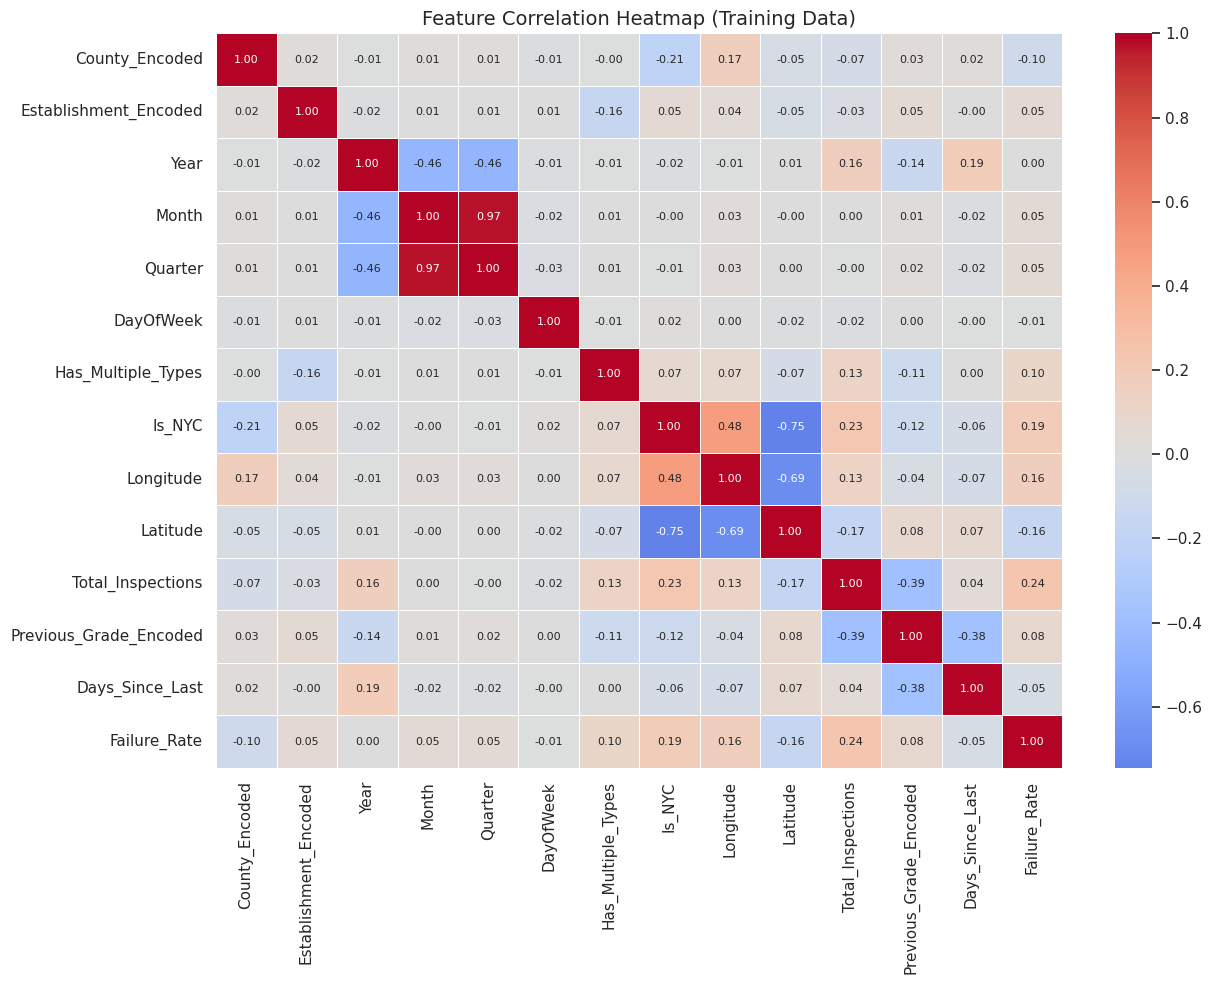

Top 10 Feature Correlations:
Month      Quarter      0.969323
Quarter    Month        0.969323
Is_NYC     Latitude     0.745248
Latitude   Is_NYC       0.745248
Longitude  Latitude     0.685726
Latitude   Longitude    0.685726
Longitude  Is_NYC       0.478721
Is_NYC     Longitude    0.478721
Quarter    Year         0.463386
Year       Quarter      0.463386
dtype: float64


In [19]:
# ── Correlation heatmap after feature engineering ────────────────
plt.figure(figsize=(13, 10))
correlation_matrix = X_train_scaled.corr()
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    annot_kws={"size": 8}
)
plt.title("Feature Correlation Heatmap (Training Data)", fontsize=14)
plt.tight_layout()
plt.show()

print("Top 10 Feature Correlations:")
corr_pairs = correlation_matrix.unstack()
corr_pairs = corr_pairs[corr_pairs < 1]
print(corr_pairs.abs().sort_values(ascending=False).head(10))

## 🤖 Build Machine Learning Models

In [20]:
# ── Train all 5 classification models ───────────────────────────
print("=" * 55)
print("MODEL TRAINING")
print("=" * 55)

# Define all models
dt_model     = DecisionTreeClassifier(random_state=42)
rf_model     = RandomForestClassifier(n_estimators=100,
                                      random_state=42, n_jobs=-1)
lr_model     = LogisticRegression(max_iter=1000,
                                  random_state=42, solver='lbfgs')
svm_linear   = SVC(kernel='linear', random_state=42,
                   max_iter=1000, probability=True)
svm_rbf      = SVC(kernel='rbf', random_state=42,
                   max_iter=1000, probability=True)

# Train all models
models = {
    'Decision Tree'      : dt_model,
    'Random Forest'      : rf_model,
    'Logistic Regression': lr_model,
    'SVM Linear'         : svm_linear,
    'SVM RBF'            : svm_rbf
}

print(f"\n{'Model':<25} {'Train Acc':>10} {'Val Acc':>10} {'Test Acc':>10}")
print("-" * 55)

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    train_acc = accuracy_score(y_train, model.predict(X_train_scaled))
    val_acc   = accuracy_score(y_val,   model.predict(X_val_scaled))
    test_acc  = accuracy_score(y_test,  model.predict(X_test_scaled))
    print(f"{name:<25} {train_acc:>10.4f} {val_acc:>10.4f} {test_acc:>10.4f}")

MODEL TRAINING

Model                      Train Acc    Val Acc   Test Acc
-------------------------------------------------------
Decision Tree                 0.9999     0.8816     0.8889
Random Forest                 0.9999     0.9108     0.9100
Logistic Regression           0.8707     0.8676     0.8684
SVM Linear                    0.7919     0.7928     0.7877
SVM RBF                       0.8456     0.8329     0.8398


# Decision Tree Visualization

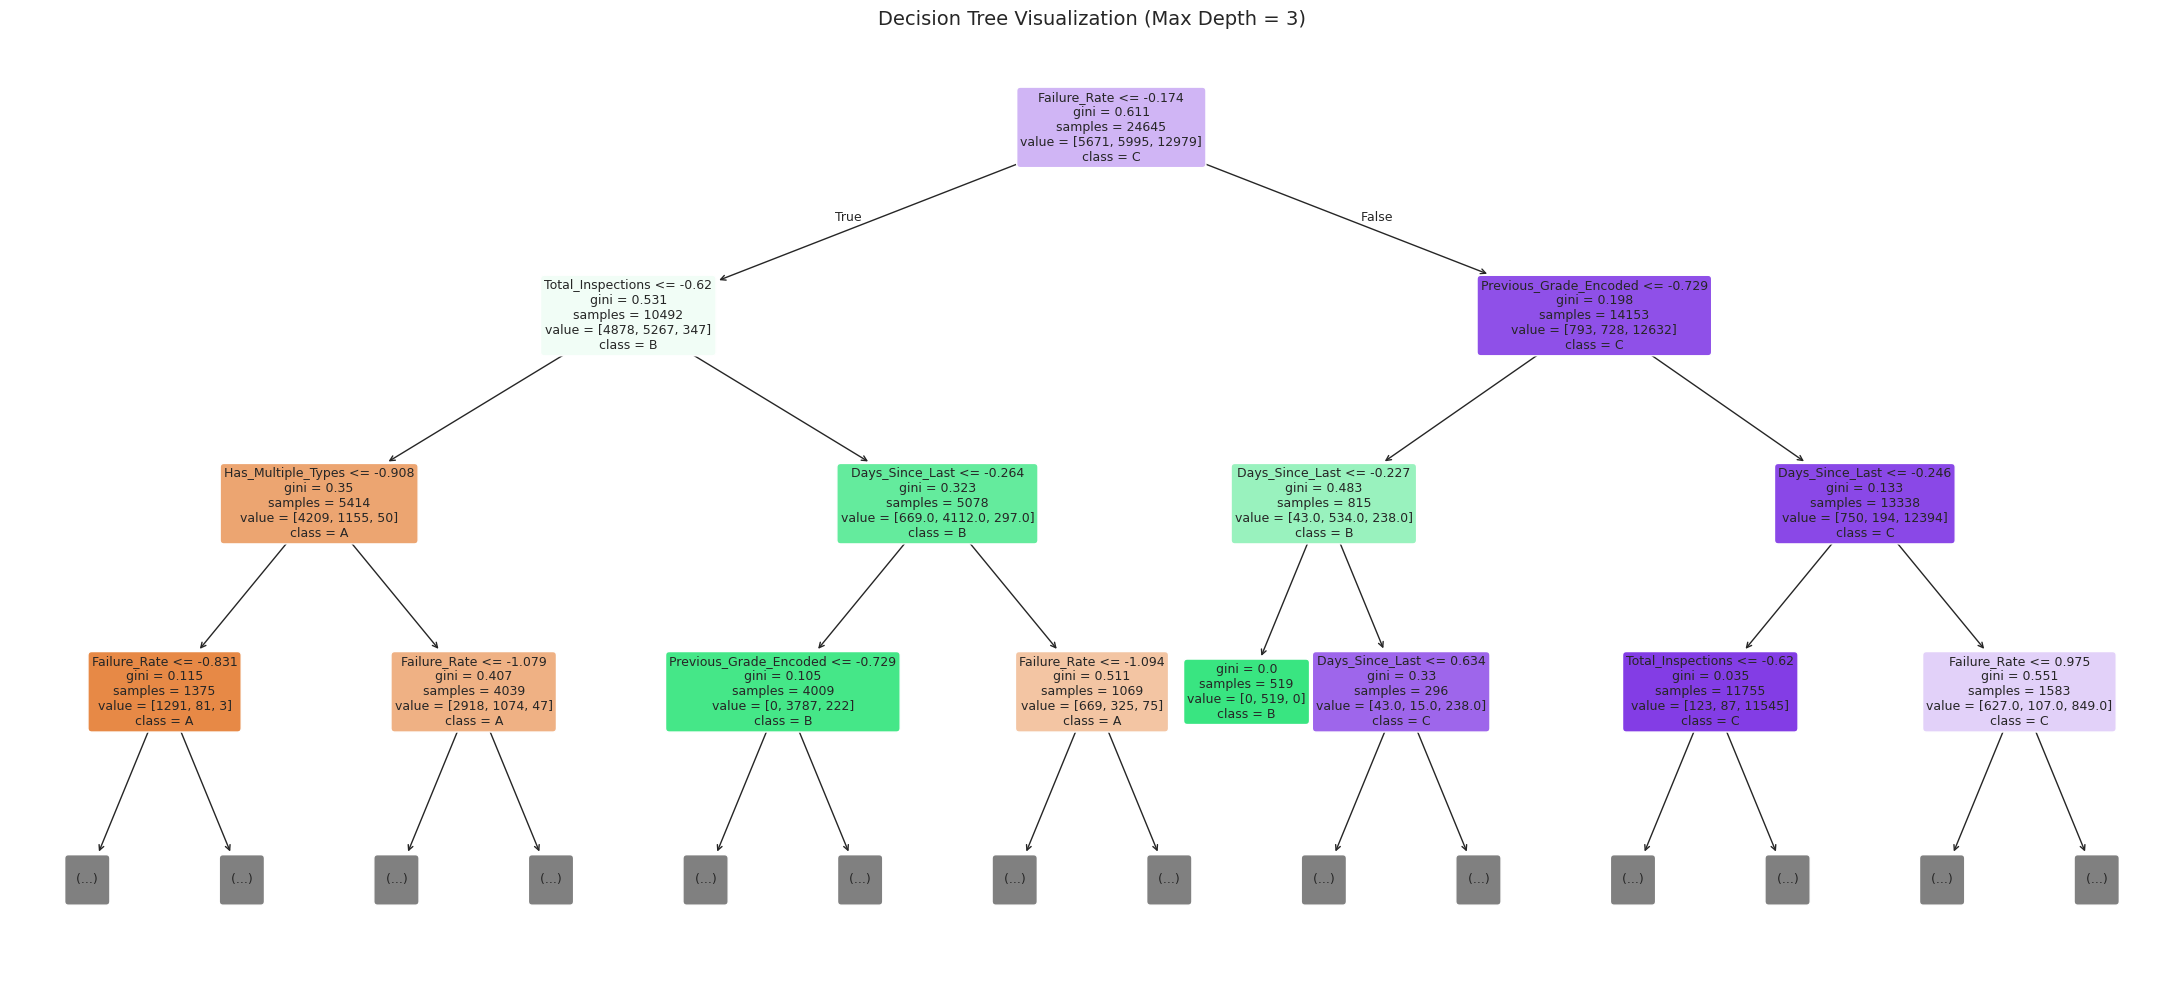

In [21]:
# ── Visualize the decision tree structure ────────────────────────
plt.figure(figsize=(22, 10))
plot_tree(
    dt_model,
    feature_names=feature_cols,
    class_names=['A', 'B', 'C'],
    filled=True,
    max_depth=3,
    fontsize=9,
    impurity=True,
    rounded=True
)
plt.title("Decision Tree Visualization (Max Depth = 3)", fontsize=14)
plt.tight_layout()
plt.show()

In [22]:
# ── Check for overfitting or underfitting ────────────────────────
print("=" * 55)
print("OVERFITTING / UNDERFITTING ANALYSIS")
print("=" * 55)

print(f"\n{'Model':<25} {'Train':>8} {'Val':>8} {'Test':>8} {'Diff':>8} {'Status'}")
print("-" * 75)

for name, model in models.items():
    train_acc = accuracy_score(y_train, model.predict(X_train_scaled))
    val_acc   = accuracy_score(y_val,   model.predict(X_val_scaled))
    test_acc  = accuracy_score(y_test,  model.predict(X_test_scaled))
    diff      = train_acc - test_acc

    if diff > 0.10:
        status = "⚠️ Overfitting"
    elif test_acc < 0.60:
        status = "⚠️ Underfitting"
    else:
        status = "✅ Good Fit"

    print(f"{name:<25} {train_acc:>8.4f} {val_acc:>8.4f} "
          f"{test_acc:>8.4f} {diff:>8.4f} {status}")

OVERFITTING / UNDERFITTING ANALYSIS

Model                        Train      Val     Test     Diff Status
---------------------------------------------------------------------------
Decision Tree               0.9999   0.8816   0.8889   0.1111 ⚠️ Overfitting
Random Forest               0.9999   0.9108   0.9100   0.0898 ✅ Good Fit
Logistic Regression         0.8707   0.8676   0.8684   0.0023 ✅ Good Fit
SVM Linear                  0.7919   0.7928   0.7877   0.0042 ✅ Good Fit
SVM RBF                     0.8456   0.8329   0.8398   0.0058 ✅ Good Fit


In [23]:
# ── Stratified K-Fold cross validation ──────────────────────────
print("=" * 55)
print("STRATIFIED K-FOLD CROSS VALIDATION (k=5)")
print("=" * 55)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print(f"\n{'Model':<25} {'CV Mean':>10} {'CV Std':>10}")
print("-" * 47)

for name, model in models.items():
    scores = cross_val_score(
        model, X_train_scaled, y_train,
        cv=cv, scoring='accuracy'
    )
    print(f"{name:<25} {scores.mean():>10.4f} {scores.std():>10.4f}")

STRATIFIED K-FOLD CROSS VALIDATION (k=5)

Model                        CV Mean     CV Std
-----------------------------------------------
Decision Tree                 0.8881     0.0049
Random Forest                 0.9111     0.0037
Logistic Regression           0.8702     0.0047
SVM Linear                    0.7309     0.0709
SVM RBF                       0.8672     0.0160


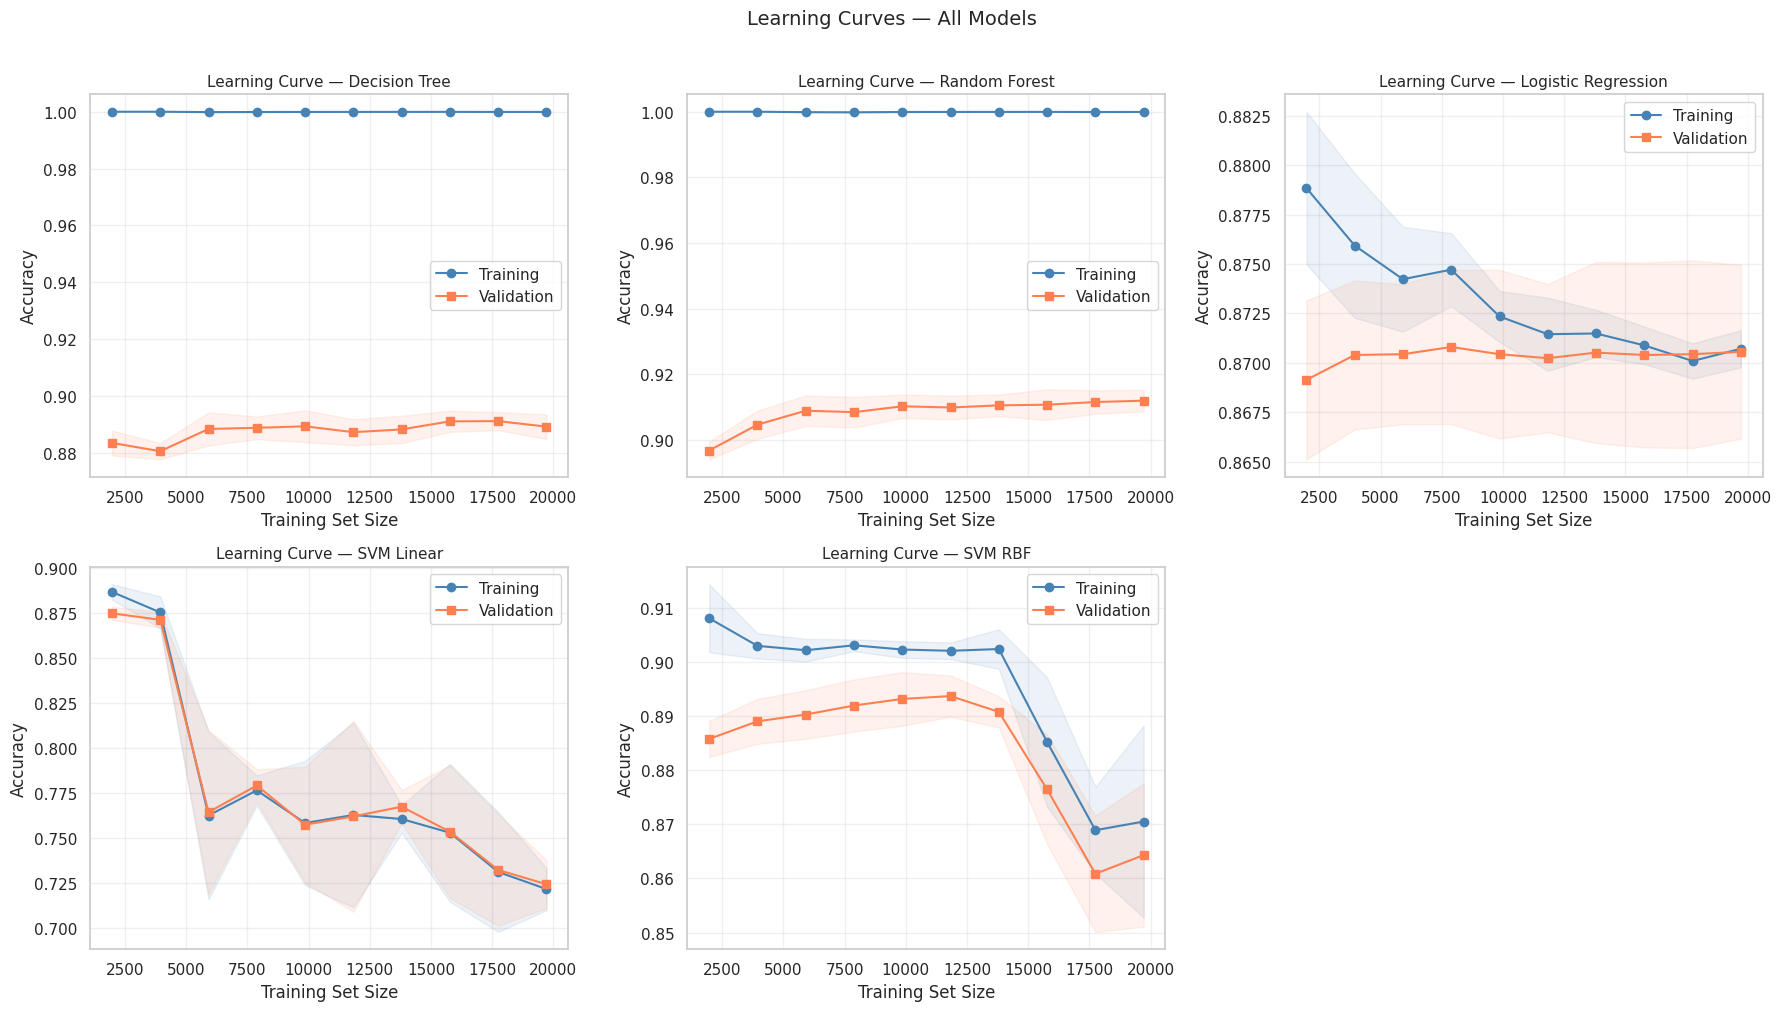

In [24]:
# ── Plot learning curves for all models ─────────────────────────
train_sizes = np.linspace(0.1, 1.0, 10)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

for idx, (name, model) in enumerate(models.items()):
    train_sizes_abs, train_scores, val_scores = learning_curve(
        model, X_train_scaled, y_train,
        train_sizes=train_sizes,
        cv=5, scoring='accuracy', n_jobs=-1
    )

    train_mean = train_scores.mean(axis=1)
    train_std  = train_scores.std(axis=1)
    val_mean   = val_scores.mean(axis=1)
    val_std    = val_scores.std(axis=1)

    axes[idx].plot(train_sizes_abs, train_mean,
                   label='Training', marker='o', color='steelblue')
    axes[idx].plot(train_sizes_abs, val_mean,
                   label='Validation', marker='s', color='coral')
    axes[idx].fill_between(train_sizes_abs,
                           train_mean - train_std,
                           train_mean + train_std, alpha=0.1,
                           color='steelblue')
    axes[idx].fill_between(train_sizes_abs,
                           val_mean - val_std,
                           val_mean + val_std, alpha=0.1,
                           color='coral')
    axes[idx].set_xlabel('Training Set Size')
    axes[idx].set_ylabel('Accuracy')
    axes[idx].set_title(f'Learning Curve — {name}', fontsize=11)
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

axes[-1].axis('off')
plt.suptitle("Learning Curves — All Models", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 🔩 Hyperparameter Tuning

In [25]:
# ── GridSearchCV on Decision Tree ────────────────────────────────
print("=" * 55)
print("HYPERPARAMETER TUNING — DECISION TREE")
print("=" * 55)

param_grid_dt = {
    'max_depth'        : [5, 10, 15, 20],
    'min_samples_split': [10, 20, 50],
    'min_samples_leaf' : [5, 10]
}

grid_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid_dt,
    cv=5, scoring='accuracy', n_jobs=-1, verbose=0
)
grid_dt.fit(X_train_scaled, y_train)

dt_tuned = grid_dt.best_estimator_

print(f"\nBest Parameters : {grid_dt.best_params_}")
print(f"Best CV Score   : {grid_dt.best_score_:.4f}")
print(f"Val  Accuracy   : {accuracy_score(y_val,  dt_tuned.predict(X_val_scaled)):.4f}")
print(f"Test Accuracy   : {accuracy_score(y_test, dt_tuned.predict(X_test_scaled)):.4f}")

HYPERPARAMETER TUNING — DECISION TREE

Best Parameters : {'max_depth': 10, 'min_samples_leaf': 10, 'min_samples_split': 50}
Best CV Score   : 0.9159
Val  Accuracy   : 0.9141
Test Accuracy   : 0.9110


In [26]:
# ── GridSearchCV on Random Forest ────────────────────────────────
print("=" * 55)
print("HYPERPARAMETER TUNING — RANDOM FOREST")
print("=" * 55)

param_grid_rf = {
    'n_estimators': [100, 150, 200],
    'max_depth'   : [10, 20, None],
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid_rf,
    cv=5, scoring='accuracy', n_jobs=-1, verbose=0
)
grid_rf.fit(X_train_scaled, y_train)

rf_tuned = grid_rf.best_estimator_

print(f"\nBest Parameters : {grid_rf.best_params_}")
print(f"Best CV Score   : {grid_rf.best_score_:.4f}")
print(f"Val  Accuracy   : {accuracy_score(y_val,  rf_tuned.predict(X_val_scaled)):.4f}")
print(f"Test Accuracy   : {accuracy_score(y_test, rf_tuned.predict(X_test_scaled)):.4f}")

HYPERPARAMETER TUNING — RANDOM FOREST

Best Parameters : {'max_depth': 10, 'n_estimators': 200}
Best CV Score   : 0.9139
Val  Accuracy   : 0.9097
Test Accuracy   : 0.9099


## ⚡ Gradient Descent Optimizer (SGD)

SGD OPTIMIZER — GRADIENT DESCENT


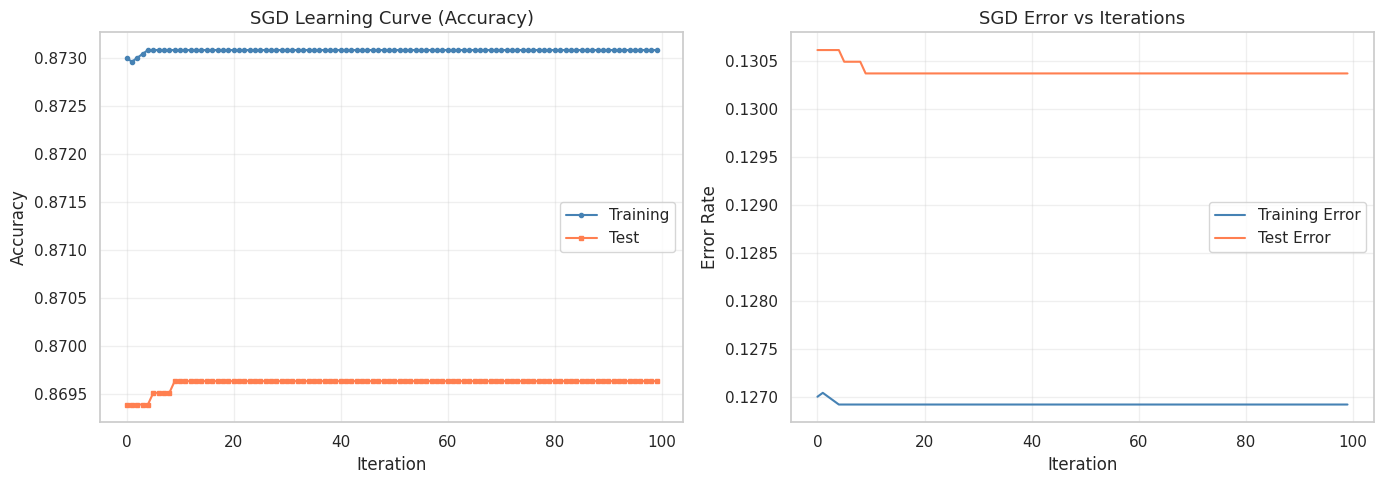


SGD Final Train Accuracy : 0.8731
SGD Final Test  Accuracy : 0.8696


In [27]:
# ── SGDClassifier with partial_fit for incremental learning ──────
print("=" * 55)
print("SGD OPTIMIZER — GRADIENT DESCENT")
print("=" * 55)

sgd_model = SGDClassifier(
    loss='log_loss',
    learning_rate='constant',
    eta0=0.01,
    random_state=42
)

n_iterations     = 100
train_accuracies = []
test_accuracies  = []

for epoch in range(n_iterations):
    # partial_fit performs one epoch of SGD
    sgd_model.partial_fit(
        X_train_scaled, y_train,
        classes=np.unique(y_train)
    )
    train_pred = sgd_model.predict(X_train_scaled)
    test_pred  = sgd_model.predict(X_test_scaled)
    train_accuracies.append(accuracy_score(y_train, train_pred))
    test_accuracies.append(accuracy_score(y_test,  test_pred))

# Plot accuracy
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(range(n_iterations), train_accuracies,
             label='Training', marker='o', markersize=3,
             color='steelblue')
axes[0].plot(range(n_iterations), test_accuracies,
             label='Test', marker='s', markersize=3,
             color='coral')
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('SGD Learning Curve (Accuracy)', fontsize=13)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot error
axes[1].plot(range(n_iterations),
             1 - np.array(train_accuracies),
             label='Training Error', color='steelblue')
axes[1].plot(range(n_iterations),
             1 - np.array(test_accuracies),
             label='Test Error', color='coral')
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('Error Rate')
axes[1].set_title('SGD Error vs Iterations', fontsize=13)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nSGD Final Train Accuracy : {train_accuracies[-1]:.4f}")
print(f"SGD Final Test  Accuracy : {test_accuracies[-1]:.4f}")

In [28]:
# ── Combine tuned and SGD models into final dictionary ───────────
final_models = {
    'Decision Tree (Tuned)' : dt_tuned,
    'Random Forest (Tuned)' : rf_tuned,
    'Logistic Regression'   : lr_model,
    'SVM Linear'            : svm_linear,
    'SVM RBF'               : svm_rbf,
    'SGD'                   : sgd_model
}

print("✓ Final models ready for evaluation:")
for name in final_models:
    print(f"  → {name}")

✓ Final models ready for evaluation:
  → Decision Tree (Tuned)
  → Random Forest (Tuned)
  → Logistic Regression
  → SVM Linear
  → SVM RBF
  → SGD


FEATURE IMPORTANCE — RANDOM FOREST


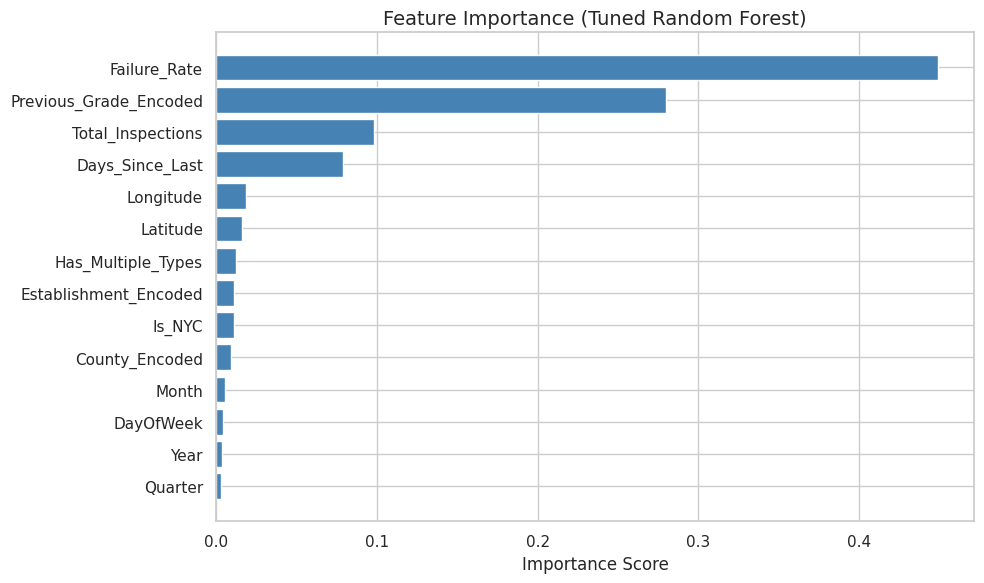


Top 10 Important Features:
               Feature  Importance
          Failure_Rate    0.448939
Previous_Grade_Encoded    0.279803
     Total_Inspections    0.098133
       Days_Since_Last    0.079104
             Longitude    0.018798
              Latitude    0.015888
    Has_Multiple_Types    0.012030
 Establishment_Encoded    0.011142
                Is_NYC    0.010885
        County_Encoded    0.009296


In [29]:
# ── Feature importance from tuned Random Forest ──────────────────
print("=" * 55)
print("FEATURE IMPORTANCE — RANDOM FOREST")
print("=" * 55)

importance_df = pd.DataFrame({
    'Feature'   : feature_cols,
    'Importance': rf_tuned.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'],
         importance_df['Importance'],
         color='steelblue')
plt.xlabel("Importance Score")
plt.title("Feature Importance (Tuned Random Forest)", fontsize=14)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\nTop 10 Important Features:")
print(importance_df.head(10).to_string(index=False))

## 📊 Model Evaluation

In [30]:
# ── Evaluate all models on all metrics ──────────────────────────
print("=" * 55)
print("MODEL EVALUATION — ALL METRICS")
print("=" * 55)

results = []
for name, model in final_models.items():
    y_pred = model.predict(X_test_scaled)
    acc    = accuracy_score(y_test, y_pred)
    prec   = precision_score(y_test, y_pred,
                             average='weighted', zero_division=0)
    rec    = recall_score(y_test, y_pred, average='weighted')
    f1     = f1_score(y_test, y_pred, average='weighted')
    results.append({
        'Model'    : name,
        'Accuracy' : round(acc,  4),
        'Precision': round(prec, 4),
        'Recall'   : round(rec,  4),
        'F1-Score' : round(f1,   4)
    })

results_df = pd.DataFrame(results).sort_values(
    'Accuracy', ascending=False
).reset_index(drop=True)
results_df.index += 1

print()
display(results_df)

MODEL EVALUATION — ALL METRICS



,Model,Accuracy,Precision,Recall,F1-Score
1,Decision Tree (Tuned),0.9110,0.9186,0.9110,0.9101
2,Random Forest (Tuned),0.9099,0.9183,0.9099,0.9084
3,SGD,0.8696,0.8705,0.8696,0.8675
4,Logistic Regression,0.8684,0.8707,0.8684,0.8669
5,SVM RBF,0.8398,0.8343,0.8398,0.8365
6,SVM Linear,0.7877,0.7979,0.7877,0.7905


In [31]:
# ── Detailed classification report per model ─────────────────────
for name, model in final_models.items():
    y_pred = model.predict(X_test_scaled)
    print(f"\n{'='*55}")
    print(f"  {name}")
    print(f"{'='*55}")
    print(classification_report(
        y_test, y_pred,
        target_names=['Grade A', 'Grade B', 'Grade C']
    ))


  Decision Tree (Tuned)
              precision    recall  f1-score   support

     Grade A       0.77      0.93      0.84      1890
     Grade B       0.95      0.74      0.83      1998
     Grade C       0.97      0.98      0.98      4327

    accuracy                           0.91      8215
   macro avg       0.90      0.88      0.88      8215
weighted avg       0.92      0.91      0.91      8215


  Random Forest (Tuned)
              precision    recall  f1-score   support

     Grade A       0.78      0.92      0.84      1890
     Grade B       0.97      0.73      0.83      1998
     Grade C       0.96      0.99      0.97      4327

    accuracy                           0.91      8215
   macro avg       0.90      0.88      0.88      8215
weighted avg       0.92      0.91      0.91      8215


  Logistic Regression
              precision    recall  f1-score   support

     Grade A       0.74      0.82      0.78      1890
     Grade B       0.87      0.71      0.78      1998
  

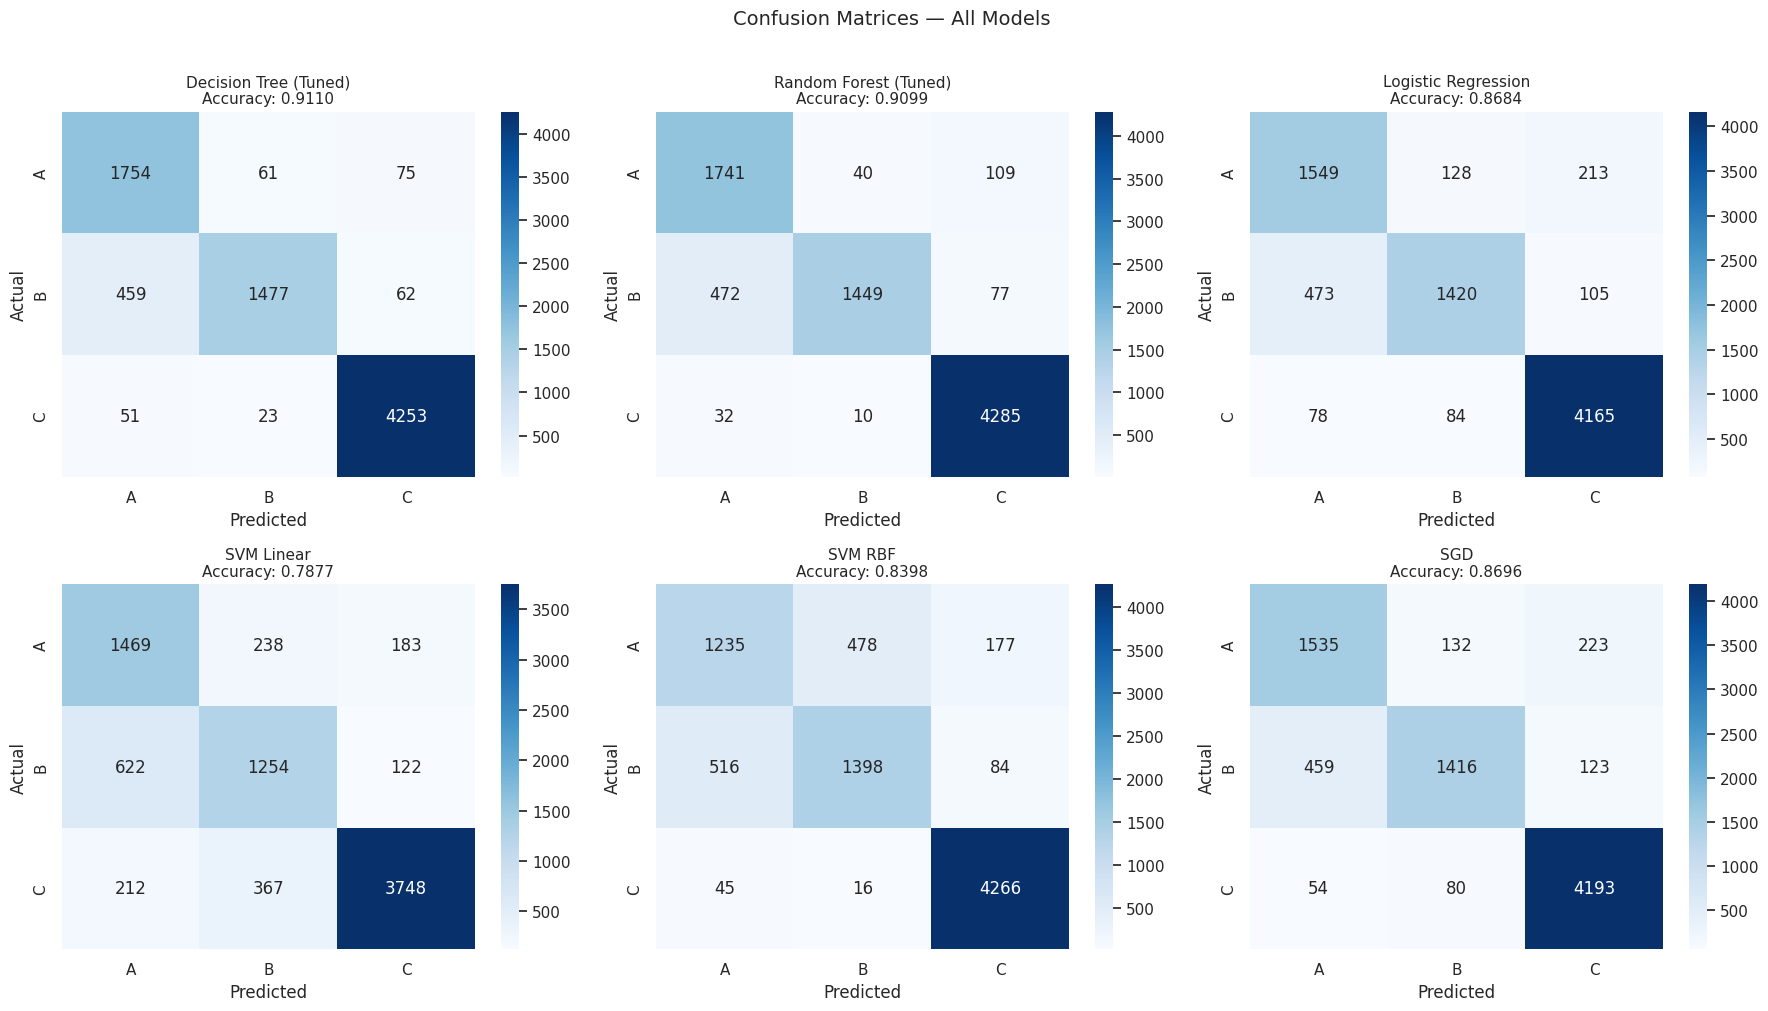

In [32]:
# ── Confusion matrix heatmap for each model ──────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

for idx, (name, model) in enumerate(final_models.items()):
    y_pred = model.predict(X_test_scaled)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
        xticklabels=['A', 'B', 'C'],
        yticklabels=['A', 'B', 'C'],
        annot_kws={"size": 12}
    )
    acc = accuracy_score(y_test, y_pred)
    axes[idx].set_title(f'{name}\nAccuracy: {acc:.4f}', fontsize=11)
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('Actual')

plt.suptitle("Confusion Matrices — All Models", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 🏆 Model Performance Comparison

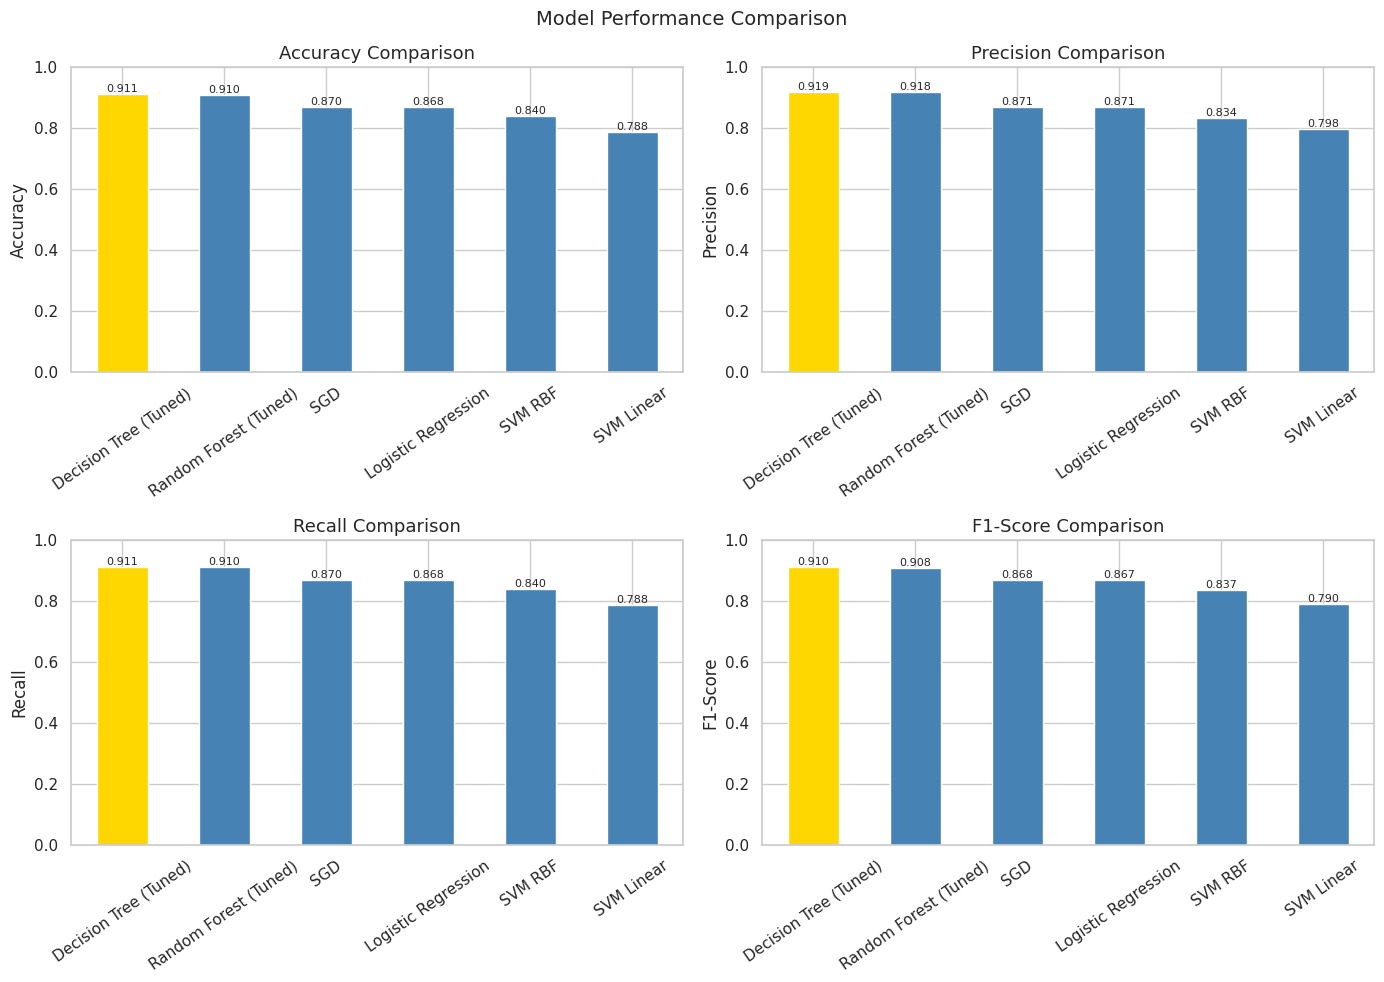

In [33]:
# ── Bar charts comparing all 4 metrics across models ────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

for idx, metric in enumerate(metrics):
    ax = axes[idx // 2, idx % 2]
    colors = ['gold' if i == 0 else 'steelblue'
              for i in range(len(results_df))]
    results_df.plot(
        x='Model', y=metric,
        kind='bar', ax=ax,
        legend=False, color=colors
    )
    ax.set_title(f'{metric} Comparison', fontsize=13)
    ax.set_xlabel('')
    ax.set_ylabel(metric)
    ax.set_ylim([0, 1.0])
    ax.tick_params(axis='x', rotation=35)
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.3f}',
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='bottom', fontsize=8)

plt.suptitle("Model Performance Comparison", fontsize=14)
plt.tight_layout()
plt.show()

TRAIN vs TEST ACCURACY


,Model,Train Accuracy,Test Accuracy,Difference
0,Decision Tree (Tuned),0.9253,0.9110,0.0143
1,Random Forest (Tuned),0.9346,0.9099,0.0247
2,Logistic Regression,0.8707,0.8684,0.0023
3,SVM Linear,0.7919,0.7877,0.0042
4,SVM RBF,0.8456,0.8398,0.0058
5,SGD,0.8731,0.8696,0.0034


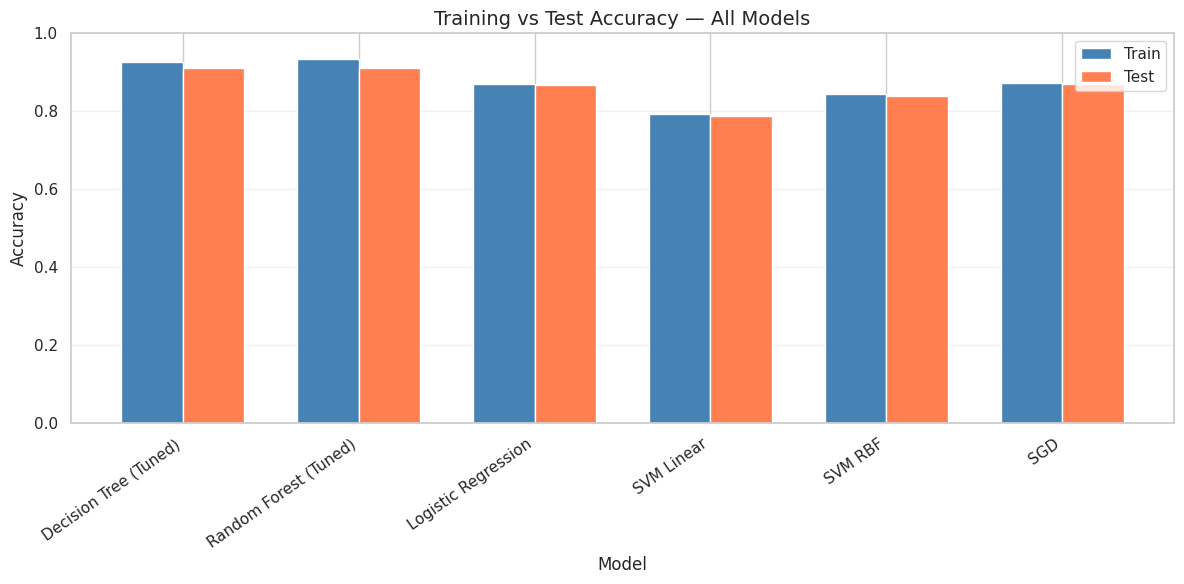

In [34]:
# ── Compare training vs test accuracy to show overfitting ────────
print("=" * 55)
print("TRAIN vs TEST ACCURACY")
print("=" * 55)

comparison = []
for name, model in final_models.items():
    train_acc = accuracy_score(y_train, model.predict(X_train_scaled))
    test_acc  = accuracy_score(y_test,  model.predict(X_test_scaled))
    diff      = train_acc - test_acc
    comparison.append({
        'Model'          : name,
        'Train Accuracy' : round(train_acc, 4),
        'Test Accuracy'  : round(test_acc,  4),
        'Difference'     : round(diff,      4)
    })

comp_df = pd.DataFrame(comparison)
display(comp_df)

# Plot
fig, ax = plt.subplots(figsize=(12, 6))
x     = np.arange(len(comp_df))
width = 0.35

ax.bar(x - width/2, comp_df['Train Accuracy'],
       width, label='Train', color='steelblue')
ax.bar(x + width/2, comp_df['Test Accuracy'],
       width, label='Test',  color='coral')

ax.set_xlabel('Model')
ax.set_ylabel('Accuracy')
ax.set_title('Training vs Test Accuracy — All Models', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(comp_df['Model'], rotation=35, ha='right')
ax.legend()
ax.set_ylim([0, 1.0])
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

BEST MODEL SUMMARY

🏆 Best Model   : Decision Tree (Tuned)
   Accuracy     : 0.9110
   Precision    : 0.9186
   Recall       : 0.9110
   F1-Score     : 0.9101


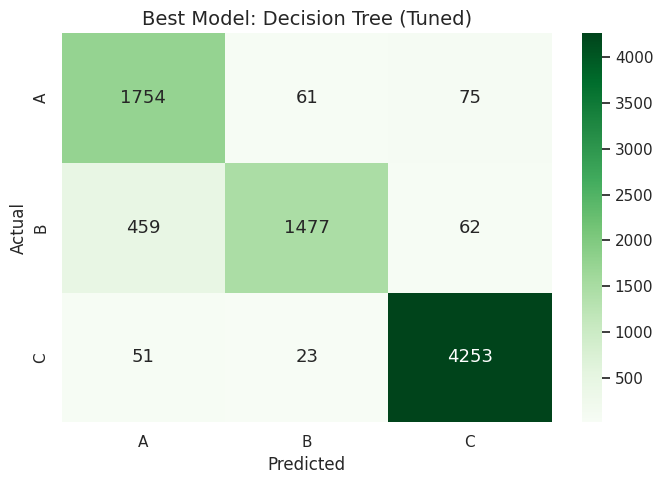


✓ Project Complete!


In [36]:
# ── Print final best model summary ──────────────────────────────
print("=" * 55)
print("BEST MODEL SUMMARY")
print("=" * 55)

best_name  = results_df.iloc[0]['Model']
best_model = final_models[best_name]
y_pred_best = best_model.predict(X_test_scaled)

print(f"\n🏆 Best Model   : {best_name}")
print(f"   Accuracy     : {results_df.iloc[0]['Accuracy']:.4f}")
print(f"   Precision    : {results_df.iloc[0]['Precision']:.4f}")
print(f"   Recall       : {results_df.iloc[0]['Recall']:.4f}")
print(f"   F1-Score     : {results_df.iloc[0]['F1-Score']:.4f}")

# Confusion matrix for best model
cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(7, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Greens',
    xticklabels=['A', 'B', 'C'],
    yticklabels=['A', 'B', 'C'],
    annot_kws={"size": 13}
)
plt.title(f'Best Model: {best_name}', fontsize=14)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

print("\n✓ Project Complete!")